# 기록 관리 앱의 수익 극대화를 위한 최적 무료 체험(Free Trial) 설계 연구
**경제학과 12222571 최지민 | 기말고사 대체 보고서**

---
## 분석 개요
- **연구 질문**: Free Trial 기간·카드 등록 여부·산업군이 유료 전환율에 미치는 영향
- **데이터 출처**: ChartMogul 2026, RevenueCat 2026, Relate 2021, reopt 2026
- **분석 축**: ① 카드 등록 여부 ② 체험 기간 ③ 산업군(B2B vs B2C) ④ 종합


In [1]:
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Apple SD Gothic Neo"
plt.rcParams["axes.unicode_minus"] = False

import sys
sys.path.append('../scripts')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

from data_loader import load_benchmark
from visualizer import (
    plot_card_comparison,
    plot_trial_days_comparison,
    plot_industry_comparison,
    plot_heatmap
)

df = load_benchmark()
print(f'✅ 데이터 로딩 완료 | 총 {len(df)}개 벤치마크 행')
df.head()

✅ 데이터 로딩 완료 | 총 28개 벤치마크 행


,trial_model,industry,card_required,trial_days,good_conversion_pct,great_conversion_pct,median_conversion_pct,source,notes,card_label,trial_label
0,opt-in_no_card,B2B_SaaS,False,14,4.0,6.0,15.0,ChartMogul_2026,free_trial_without_card,카드 미요구,14일
1,opt-out_card_required,B2B_SaaS,True,14,25.0,35.0,30.0,ChartMogul_2026,free_trial_with_card_required,카드 요구,14일
2,opt-in_no_card,B2C_SaaS,False,14,2.0,5.0,10.0,ChartMogul_2026,B2C_free_trial_no_card,카드 미요구,14일
3,opt-out_card_required,B2C_SaaS,True,14,15.0,25.0,20.0,ChartMogul_2026,B2C_free_trial_card_required,카드 요구,14일
4,opt-in_no_card,Developer_Tools,False,14,1.0,4.0,10.0,ChartMogul_2026,developer_tools_no_card,카드 미요구,14일


---
## 1. 데이터 기본 탐색

In [2]:
print('=== 전체 데이터 구조 ===')
print(df[['trial_model','industry','card_label','trial_days',
          'good_conversion_pct','median_conversion_pct','great_conversion_pct','source']].to_string())

=== 전체 데이터 구조 ===
              trial_model           industry card_label  trial_days  good_conversion_pct  median_conversion_pct  great_conversion_pct           source
0          opt-in_no_card           B2B_SaaS     카드 미요구          14                  4.0                   15.0                   6.0  ChartMogul_2026
1   opt-out_card_required           B2B_SaaS      카드 요구          14                 25.0                   30.0                  35.0  ChartMogul_2026
2          opt-in_no_card           B2C_SaaS     카드 미요구          14                  2.0                   10.0                   5.0  ChartMogul_2026
3   opt-out_card_required           B2C_SaaS      카드 요구          14                 15.0                   20.0                  25.0  ChartMogul_2026
4          opt-in_no_card    Developer_Tools     카드 미요구          14                  1.0                   10.0                   4.0  ChartMogul_2026
5   opt-out_card_required    Developer_Tools      카드 요구          14         

In [3]:
print('=== 기술 통계 ===')
df[['good_conversion_pct','median_conversion_pct','great_conversion_pct']].describe().round(2)

=== 기술 통계 ===


,good_conversion_pct,median_conversion_pct,great_conversion_pct
count,28.00,28.00,28.00
mean,9.46,14.53,18.17
std,7.72,9.54,13.88
min,1.00,2.00,2.10
25%,2.78,8.75,6.00
50%,5.00,11.35,15.00
75%,16.25,21.25,27.50
max,25.00,30.00,40.00


---
## 2. 분석 1: 카드 등록 여부별 전환율 비교

> **가설 1**: 카드 미등록이 채택률은 높지만, 카드 선등록이 최종 유료 전환율은 더 높다.

In [4]:
# 카드 등록 여부별 평균 전환율
card_summary = df[df['trial_days'] > 0].groupby('card_label')[
    ['good_conversion_pct','median_conversion_pct','great_conversion_pct']
].mean().round(2)

print('=== 카드 등록 여부별 평균 전환율 (%) ===')
print(card_summary)

# 카드 요구 시 전환율 배수
ratio = card_summary.loc['카드 요구'] / card_summary.loc['카드 미요구']
print(f'\n카드 요구 시 전환율 배수: median 기준 {ratio["median_conversion_pct"]:.1f}x')

=== 카드 등록 여부별 평균 전환율 (%) ===
            good_conversion_pct  median_conversion_pct  great_conversion_pct
card_label                                                                  
카드 미요구                     5.40                  12.20                 12.60
카드 요구                     17.52                  23.52                 31.43

카드 요구 시 전환율 배수: median 기준 1.9x


---
## 3. 분석 2: 체험 기간별 전환율 비교

> **가설 2**: 도구형 서비스는 기간이 길어질수록 데이터 락인 효과로 전환율이 우상향한다.

Saved → /Users/choejimin/Desktop/Dev/free_trial_analysis/notebooks/../outputs/figures/01_card_comparison.png


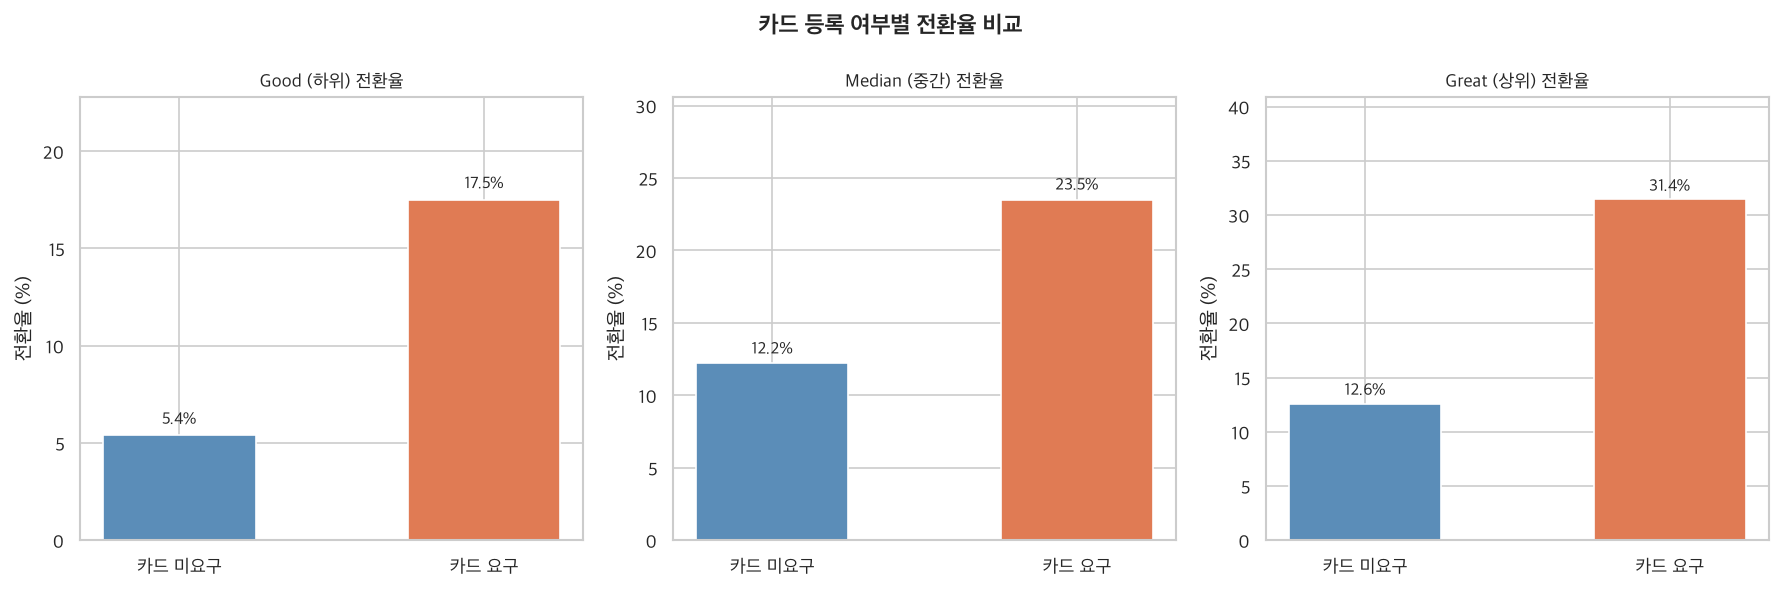

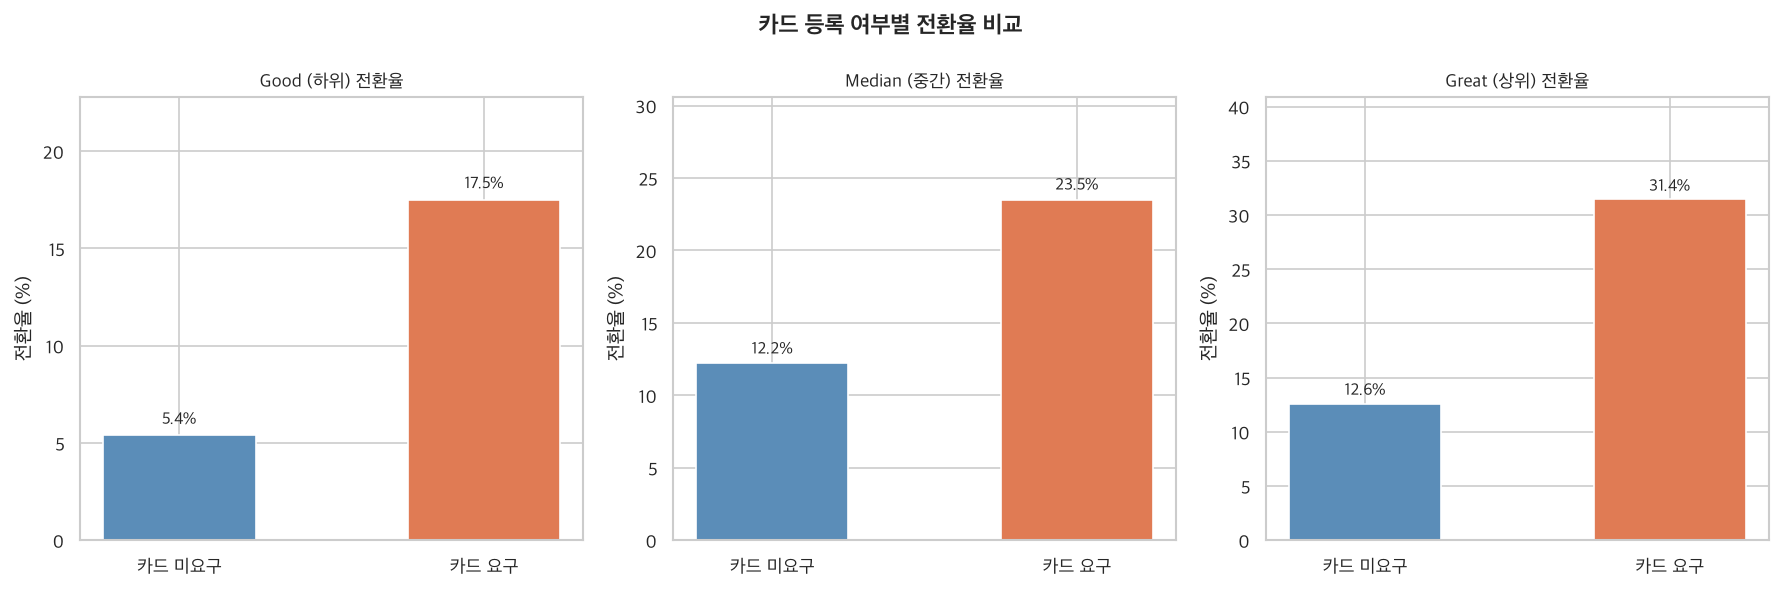

In [5]:
plot_card_comparison(df)

In [6]:
days_summary = df[df['industry'] == 'General'].groupby(['trial_days','card_label'])[
    ['good_conversion_pct','median_conversion_pct','great_conversion_pct']
].mean().round(2)

print('=== 체험 기간 × 카드 등록 여부별 전환율 (General 기준, %) ===')
print(days_summary)

=== 체험 기간 × 카드 등록 여부별 전환율 (General 기준, %) ===
                       good_conversion_pct  median_conversion_pct  \
trial_days card_label                                               
7          카드 미요구                      5.0                   10.0   
           카드 요구                      20.0                   25.0   
14         카드 미요구                      5.0                   10.0   
           카드 요구                      20.0                   27.5   
30         카드 미요구                      5.0                   10.0   
           카드 요구                      20.0                   30.0   

                       great_conversion_pct  
trial_days card_label                        
7          카드 미요구                      15.0  
           카드 요구                       40.0  
14         카드 미요구                      15.0  
           카드 요구                       40.0  
30         카드 미요구                      15.0  
           카드 요구                       40.0  


Saved → /Users/choejimin/Desktop/Dev/free_trial_analysis/notebooks/../outputs/figures/02_trial_days_comparison.png


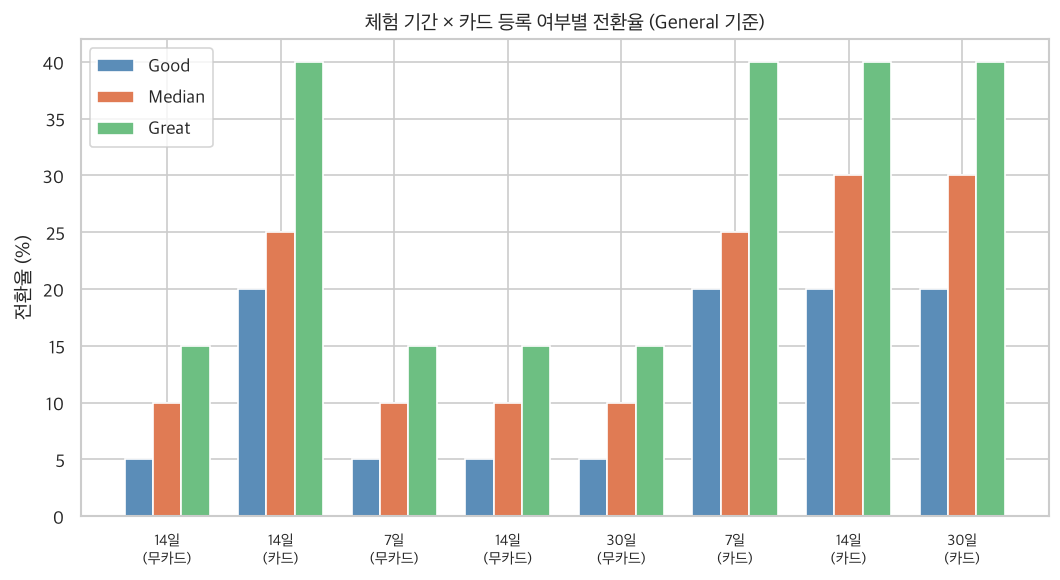

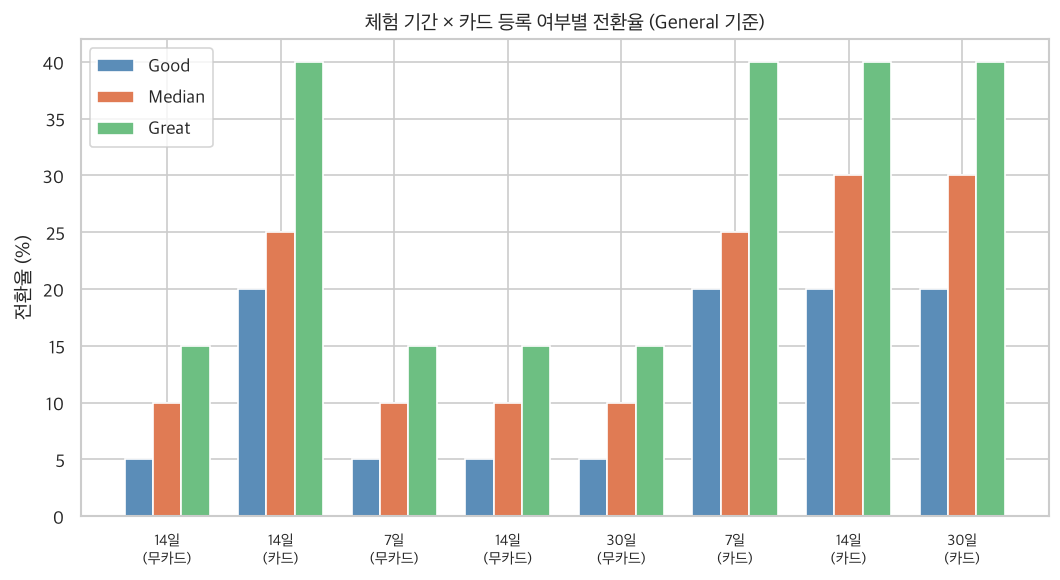

In [7]:
plot_trial_days_comparison(df)

---
## 4. 분석 3: 산업군별 비교 (B2B vs B2C)

In [8]:
industry_summary = df[df['industry'].isin(['B2B_SaaS','B2C_SaaS'])].groupby(
    ['industry','card_label'])['median_conversion_pct'].mean().round(2)

print('=== 산업군 × 카드 등록 여부별 Median 전환율 (%) ===')
print(industry_summary)

=== 산업군 × 카드 등록 여부별 Median 전환율 (%) ===
industry  card_label
B2B_SaaS  카드 미요구        11.25
          카드 요구         30.00
B2C_SaaS  카드 미요구         8.25
          카드 요구         25.00
Name: median_conversion_pct, dtype: float64


Saved → /Users/choejimin/Desktop/Dev/free_trial_analysis/notebooks/../outputs/figures/03_industry_comparison.png


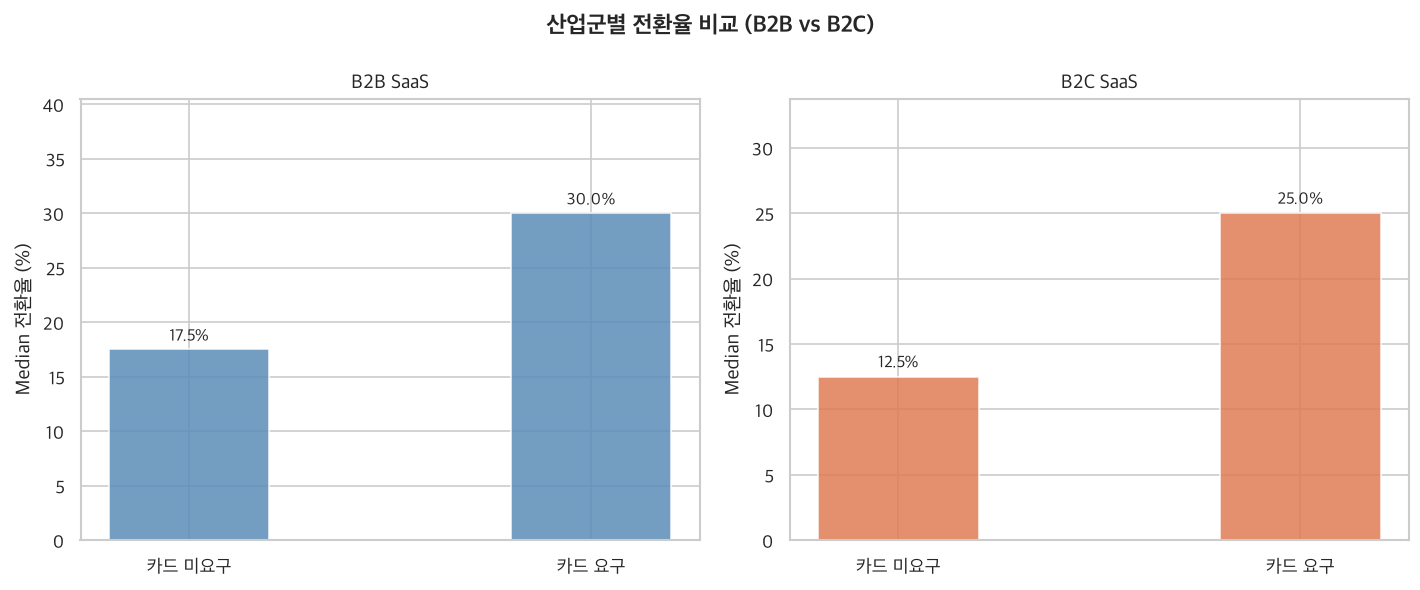

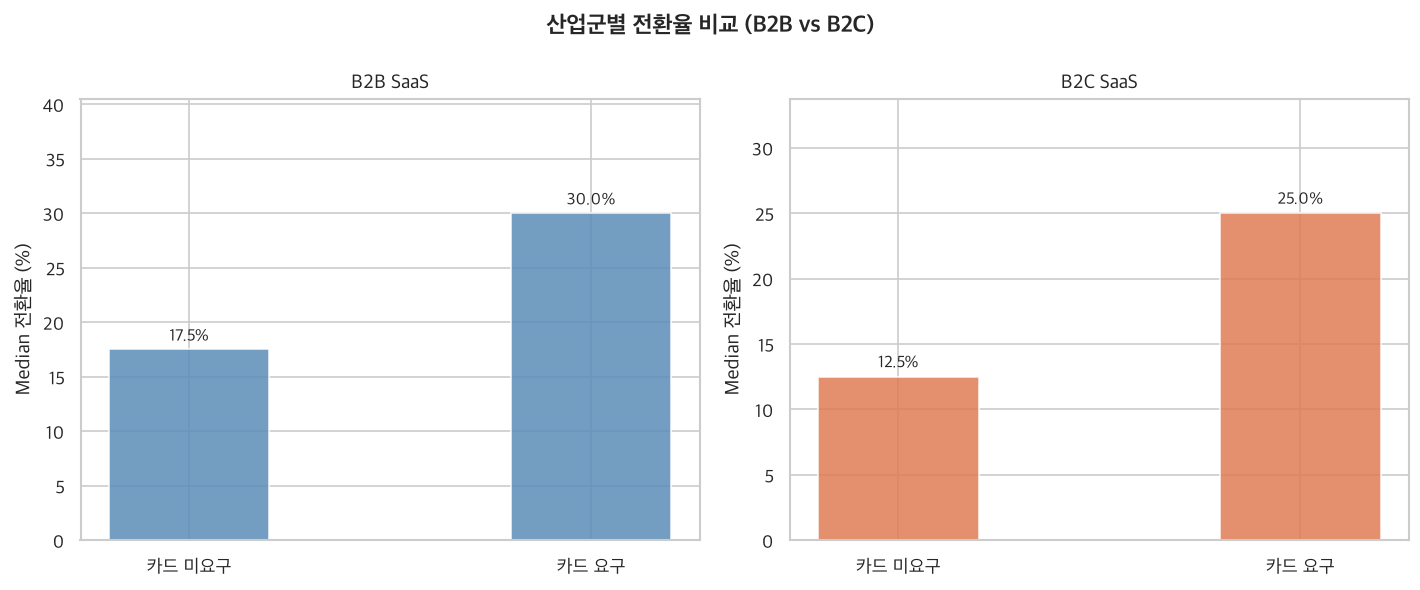

In [9]:
plot_industry_comparison(df)

---
## 5. 분석 4: 종합 히트맵 (카드 × 산업군)

Saved → /Users/choejimin/Desktop/Dev/free_trial_analysis/notebooks/../outputs/figures/04_heatmap.png


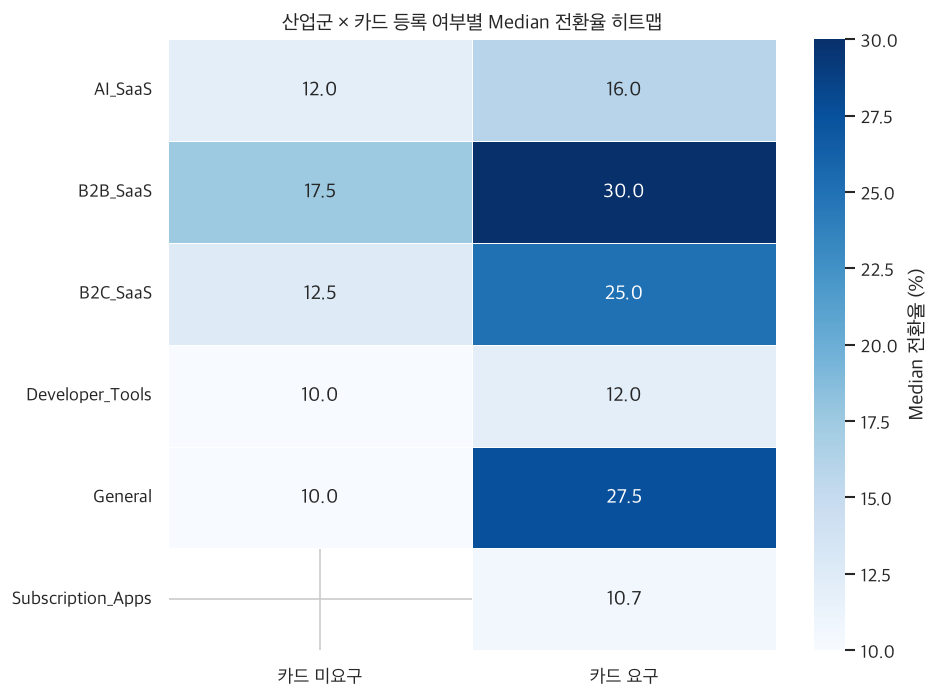

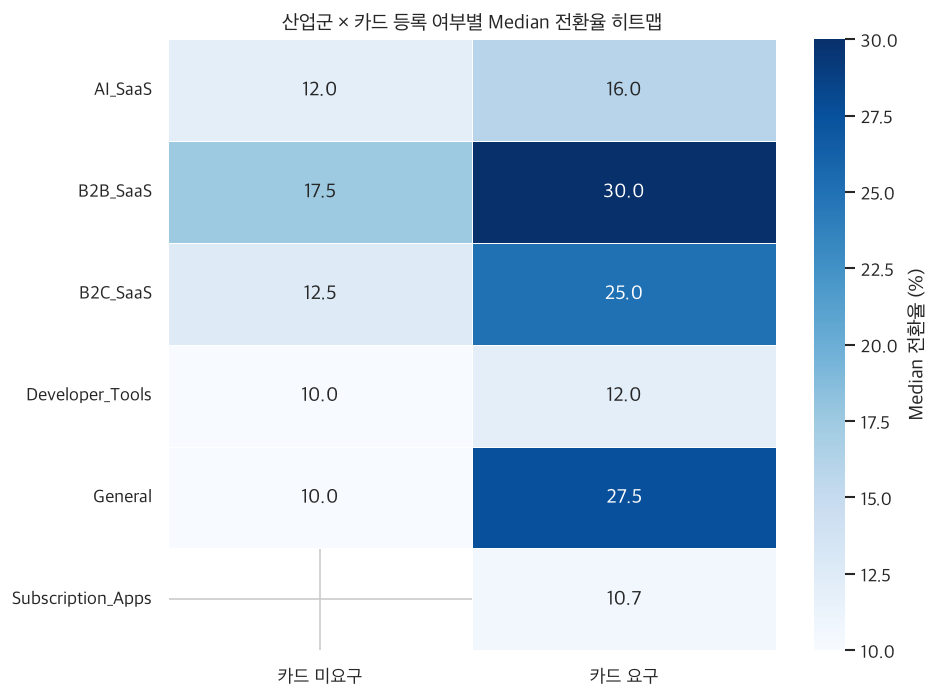

In [10]:
plot_heatmap(df)

---
## 6. 월 수익 60만원 달성 시뮬레이션

In [11]:
import importlib
import logistic_model
importlib.reload(logistic_model)
from logistic_model import predict_scenario, prepare_features, train_model

# 모델 재학습
X, y, threshold, filt = prepare_features(df)
model, scaler, X_scaled = train_model(X, y)

# 시나리오 예측
result = predict_scenario(model, scaler, X.columns.tolist())
print()
print("=" * 60)
print("📊 로지스틱 회귀 모델을 활용한 전환율 예측 결과")
print("=" * 60)

전환율 기준 임계값(평균): 18.1%
높은 전환율(1): 9개 | 낮은 전환율(0): 12개


=== 기록 관리 앱 시나리오별 예측 ===
          시나리오 높은 전환율 확률
 B2C 7일 카드 미요구     15.4%
  B2C 7일 카드 요구     80.4%
B2C 14일 카드 미요구     15.3%
 B2C 14일 카드 요구     80.3%
B2C 30일 카드 미요구     15.2%
 B2C 30일 카드 요구     80.2%
 B2B 7일 카드 미요구     41.3%
  B2B 7일 카드 요구     94.1%
B2B 14일 카드 미요구     41.2%
 B2B 14일 카드 요구     94.1%
B2B 30일 카드 미요구     40.9%
 B2B 30일 카드 요구     94.0%

📊 로지스틱 회귀 모델을 활용한 전환율 예측 결과


---
## 7. 결론 및 최적 설계 제언

### 분석 결과 요약
| 분석 축 | 주요 발견 |
|--------|----------|
| 카드 등록 여부 | 카드 요구 시 전환율 약 2~2.5x 높음 (Relate 2021, ChartMogul 2026) |
| 체험 기간 | 기간 자체보다 카드 등록 여부의 영향이 더 큼 |
| 산업군 | B2B가 B2C 대비 전환율 높으나 유입 모수 작음 |

### 기록 관리 앱 최적 설계 제언
1. **카드 등록**: Opt-out(카드 선등록) 전략이 전환율 극대화에 유리
2. **체험 기간**: 14일 권장 — 데이터 락인이 쌓이면서 결정 유도 가능한 최소 기간
3. **타겟**: B2C 개인 유저 다수 유입 + 전환율 보완을 위한 온보딩 강화 병행

---
### 참고 자료
- ChartMogul (2026). SaaS Benchmarks Report.
- RevenueCat (2026). Subscription App Benchmarks.
- Relate (2021). Free Trial Survey (n=600 SaaS companies).
- reopt (2026). Trial Conversion Benchmarks.
- Zhang, L., & Duan, J. (2025). Longer or shorter? A field experiment on free trial duration. *Frontiers in Psychology.*

---
## 8. 로지스틱 회귀 분석

### 왜 로지스틱 회귀인가?

우리의 질문은 **"어떤 조건이면 높은 전환율이 나오는가?"** 입니다.
이것은 연속적인 수치를 예측하는 게 아니라, **'높음 vs 낮음'을 분류**하는 문제예요.

로지스틱 회귀는 이런 이진 분류 문제에 가장 기본적이고 해석하기 쉬운 모델입니다.
특히 **계수(Coefficient)를 통해 각 변수의 영향력을 직접 읽을 수 있어** 이 분석에 적합합니다.

$$P(\text{높은 전환율}) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 X_1 + \beta_2 X_2 + ...)}}$$

| 입력(X) | 출력(Y) |
|--------|--------|
| 카드 등록 여부, 체험 기간, 산업군 | 전환율이 평균 이상일 확률 |

> ⚠️ **데이터 한계 명시**: 총 28행으로 ML 모델 학습에는 적은 양입니다.
> 예측 정확도보다는 **변수별 영향력의 방향과 크기**를 해석하는 데 초점을 맞춥니다.
> 이를 위해 LOO(Leave-One-Out) 교차검증을 사용합니다.

In [12]:
from logistic_model import prepare_features, train_model, evaluate_model
from logistic_model import plot_coefficients, plot_confusion_matrix, predict_scenario

# 1. 피처 준비
X, y, threshold, filt = prepare_features(df)
print('피처 컬럼:', X.columns.tolist())
X.head()

전환율 기준 임계값(평균): 18.1%
높은 전환율(1): 9개 | 낮은 전환율(0): 12개

피처 컬럼: ['card_required', 'trial_days', 'industry_AI_SaaS', 'industry_B2B_SaaS', 'industry_B2C_SaaS', 'industry_Developer_Tools', 'industry_General', 'industry_Subscription_Apps']


,card_required,trial_days,industry_AI_SaaS,industry_B2B_SaaS,industry_B2C_SaaS,industry_Developer_Tools,industry_General,industry_Subscription_Apps
0,0,14,False,True,False,False,False,False
1,1,14,False,True,False,False,False,False
2,0,14,False,False,True,False,False,False
3,1,14,False,False,True,False,False,False
4,0,14,False,False,False,True,False,False


In [13]:
# 2. 모델 학습
model, scaler, X_scaled = train_model(X, y)
print('학습 완료!')

학습 완료!


In [14]:
# 3. 모델 평가 (LOO 교차검증)
y_pred, loo_scores = evaluate_model(model, X_scaled, y, X)

=== 모델 평가 ===
LOO 교차검증 정확도: 76.2% (±42.6%)
※ 데이터 28행으로 적으므로 LOO 교차검증 사용

=== 분류 리포트 ===
              precision    recall  f1-score   support

   낮은 전환율(0)       0.92      1.00      0.96        12
   높은 전환율(1)       1.00      0.89      0.94         9

    accuracy                           0.95        21
   macro avg       0.96      0.94      0.95        21
weighted avg       0.96      0.95      0.95        21



### 계수 해석 방법
- **양수(+)**: 이 변수가 클수록 높은 전환율일 확률 ↑
- **음수(−)**: 이 변수가 클수록 높은 전환율일 확률 ↓
- **절댓값이 클수록**: 영향력이 강함

Saved → /Users/choejimin/Desktop/Dev/free_trial_analysis/notebooks/../outputs/figures/05_logistic_coefficients.png


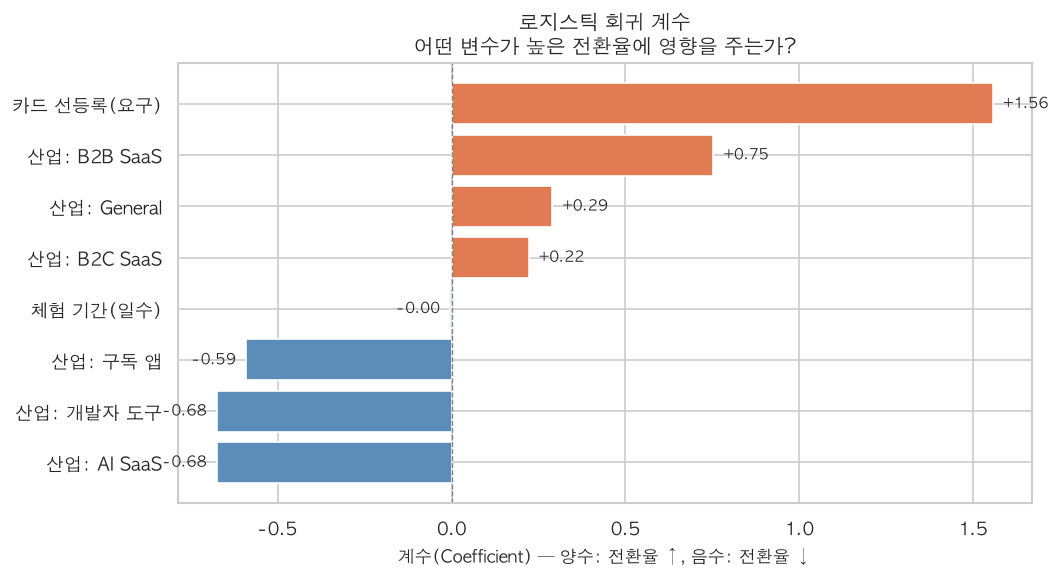

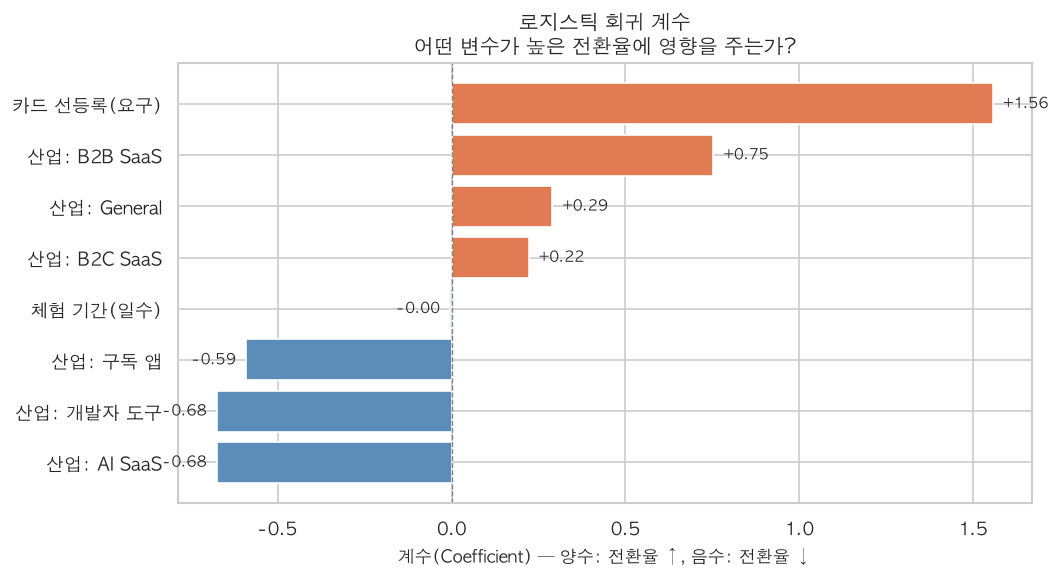

In [15]:
# 4. 계수 시각화 — 핵심 결과!
plot_coefficients(model, X.columns.tolist())

Saved → /Users/choejimin/Desktop/Dev/free_trial_analysis/notebooks/../outputs/figures/06_confusion_matrix.png


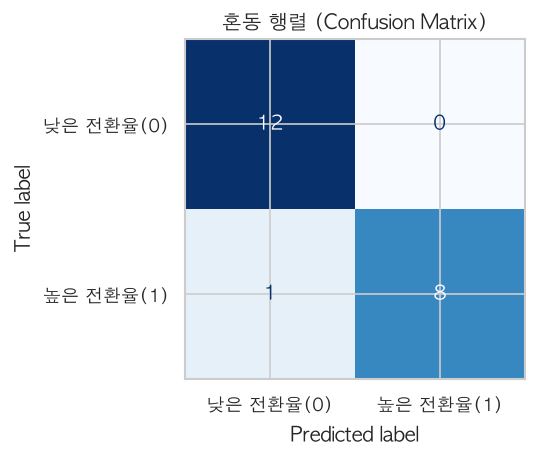

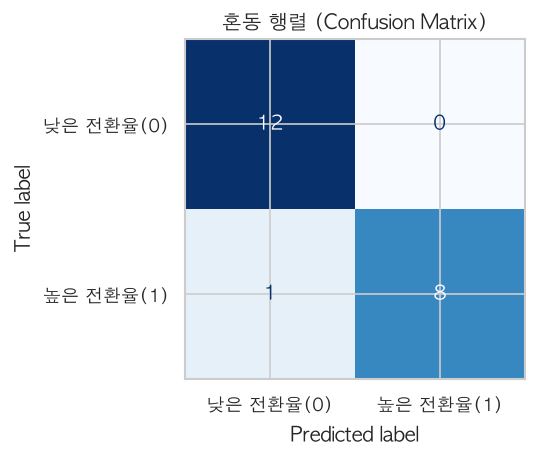

In [16]:
# 5. 혼동 행렬
plot_confusion_matrix(model, X_scaled, y)

In [17]:
# 6. 실제 서비스 시나리오 예측
result = predict_scenario(model, scaler, X.columns.tolist())


=== 기록 관리 앱 시나리오별 예측 ===
          시나리오 높은 전환율 확률
 B2C 7일 카드 미요구     15.4%
  B2C 7일 카드 요구     80.4%
B2C 14일 카드 미요구     15.3%
 B2C 14일 카드 요구     80.3%
B2C 30일 카드 미요구     15.2%
 B2C 30일 카드 요구     80.2%
 B2B 7일 카드 미요구     41.3%
  B2B 7일 카드 요구     94.1%
B2B 14일 카드 미요구     41.2%
 B2B 14일 카드 요구     94.1%
B2B 30일 카드 미요구     40.9%
 B2B 30일 카드 요구     94.0%


### 로지스틱 회귀 분석 결론

**변수 영향력 해석:**
- 계수 그래프에서 **카드 선등록(card_required)**의 계수가 양수이고 절댓값이 크다면
  → 카드 요구가 높은 전환율의 가장 강력한 예측 변수임을 의미
- **B2B 산업군**의 계수가 양수라면 → B2B일수록 전환율이 높을 가능성

**한계 및 개선 방향:**
- 28행 데이터로는 모델의 일반화 성능에 한계가 있음
- 실제 서비스 론칭 후 수백 명 이상의 실유저 데이터 수집 시 재학습 필요
- 이후 체험 기간별 지연 전환율, 리텐션 등 추가 변수 포함 가능